# Swahili News Classification: Data Investigation and Model Selection

*Formative Assignment 2: NLP and Language Technologies*

**Dataset:** [Swahili News Classification Challenge (Zindi)](https://zindi.world/competitions/swahili-news-classification-challenge): 5,151 labelled news articles from Tanzanian news websites in five categories (David, 2020).

This notebook covers the first two stages of the project:

1. **Exploratory data analysis (Sections 1-7):** the properties of the data that matter for a sequential model, namely class balance, article length in words and in subword tokens, data-quality problems, vocabulary and morphology.
2. **Evaluation metrics, related work and model selection (Sections 8-11):** how performance is measured, what earlier research found, and the five approaches compared in this study.

`02_baselines.ipynb` trains the two TF-IDF baselines and `03_neural_models.ipynb` trains the three neural sequence models and compares all five.

## Key findings

1. **Severe class imbalance.** `Kitaifa` 38.8%, `michezo` 33.4% and `Biashara` 26.4%, but `Kimataifa` only 1.0% (54 articles) and `Burudani` only 0.3% (17 articles). We therefore use **macro-F1** as the primary metric and **stratified** splits; a random split can leave `Burudani` with no validation examples.
2. **255 `michezo` records are malformed.** About 15% of the sports class is stored as stringified Python lists (`['para 1...', 'para 2...']`), a scraping artefact. They are parsed and re-joined before tokenisation (Section 4).
3. **Rich morphology.** 53.5% of the 74k distinct word forms occur only once, which motivates subword tokenisation (Section 5).
4. **Long articles.** The median article has 271 words, and length differs by category, and 26.5% of articles are longer than AfriBERTa's 510-token limit, far more often in `Kitaifa` than in `Burudani` (Sections 3 and 5.1).
5. **Label noise between `Biashara` and `Kitaifa`.** 8 near-duplicate article pairs have conflicting labels, 7 of them business vs national news (Section 4).

## Setup
Run this cell first. On Google Colab it clones the repository and asks you to upload `Train.csv` (and `Test.csv`) from the Zindi data page; locally it only adds the repository root to the Python path.

In [1]:
import sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("src").exists():
    if not Path("/content/formativeII-NLP").exists():
        !git clone -q https://github.com/mukunzindahiro-max/formativeII-NLP.git /content/formativeII-NLP
    %cd /content/formativeII-NLP

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.data import DATA_DIR

if "google.colab" in sys.modules and not (DATA_DIR / "Train.csv").exists():
    from google.colab import files
    for name, content in files.upload().items():
        (DATA_DIR / name).write_bytes(content)

In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import FIGURES_DIR, clean_content, load_raw

pd.set_option("display.max_colwidth", 120)

train = load_raw("Train.csv")
test = load_raw("Test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()

Train shape: (5151, 3)
Test shape : (1288, 2)


,id,content,category
0,SW0,SERIKALI imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya...,Kitaifa
1,SW1,"Mkuu wa Mkoa wa Tabora, Aggrey Mwanri amesitisha likizo za viongozi wote mkoani humo kutekeleza maazimio ya Jukwaa ...",Biashara
2,SW10,SERIKALI imetoa miezi sita kwa taasisi zote za umma ambazo hazitumii mfumo wa GePG katika ukusanyaji wa fedha kufan...,Kitaifa
3,SW100,KAMPUNI ya mchezo wa kubahatisha ya M-bet imeingia makubaliano ya udhamini na timu ya soka ya Manispaa ya Kinondoni...,michezo
4,SW1000,"WATANZANIA wamekumbushwa kusherehekea sikukuu ya Krismasi kwa kuenzi amani, umoja na kulinda tamaduni za nchi ili k...",Kitaifa


## 1. Basic integrity checks
Missing values, duplicate content, and the train/test ID scheme.

In [3]:
print("Missing values (train):\n", train.isna().sum())
print()
print("Duplicate content rows:", train['content'].duplicated().sum())
print("Duplicate ids:", train['id'].duplicated().sum())
print()
print("Train ID sample:", train['id'].head(3).tolist())
print("Test  ID sample:", test['swahili_id'].head(3).tolist())

Missing values (train):
 id          0
content     0
category    0
dtype: int64

Duplicate content rows: 0
Duplicate ids: 0

Train ID sample: ['SW0', 'SW1', 'SW10']
Test  ID sample: ['001dd47ac202d9db6624a5ff734a5e7dddafeaf2', '0043d97f7690e9bc02f0ed8bb2b260d1d44bad92', '00579c2307b5c11003d21c40c3ecff5e922c3fd8']


Train and test use different ID schemes (`SW#` in train, long hashes in test), so there is no risk of leakage through IDs.

## 2. Class distribution
The competition is a 5-way classification task over Swahili news categories. This is the
single most important characteristic of the dataset — it determines the evaluation metric,
the training/validation strategy, and rules out plain accuracy as a meaningful metric.

           count  percent
category                 
Kitaifa     2000    38.83
michezo     1720    33.39
Biashara    1360    26.40
Kimataifa     54     1.05
Burudani      17     0.33


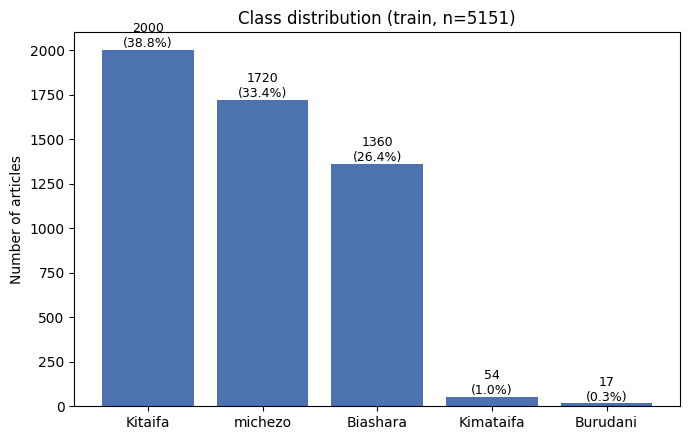

In [4]:
counts = train['category'].value_counts()
props = train['category'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': counts, 'percent': props.round(2)})
print(summary)

order = counts.index.tolist()
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(order, [counts[c] for c in order], color='#4C72B0')
ax.set_ylabel("Number of articles")
ax.set_title(f"Class distribution (train, n={len(train)})")
for b, c in zip(bars, [counts[o] for o in order]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, f"{c}\n({100*c/len(train):.1f}%)", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig1_class_distribution.png", dpi=150)
plt.show()

**Finding:** the classes are severely imbalanced. `Kitaifa` (national, 38.8%),
`michezo` (sports, 33.4%) and `Biashara` (business, 26.4%) together account for ~99% of
the data, while `Kimataifa` (international) has only 54 examples (1.0%) and `Burudani`
(entertainment) only 17 (0.3%). This has direct modelling implications:
- **Macro-F1** (not accuracy, and not micro-F1) is the appropriate evaluation metric, since
  accuracy would be dominated by the three majority classes.
- The two minority classes are too small for a conventional train/val/test split to leave
  enough validation examples — stratified k-fold, class-weighted loss, or oversampling
  (e.g. back-translation augmentation) should be considered.
- Any model comparison must report per-class F1, not just an aggregate score, or the
  near-absence of `Burudani`/`Kimataifa` signal will be invisible.

## 3. Document length
Sequence length drives architecture choices directly: it sets the truncation/padding length
for RNN/Transformer models and affects whether long-range dependencies actually matter for
this task.

In [5]:
train['n_words'] = train['content'].astype(str).str.split().apply(len)
train['n_chars'] = train['content'].astype(str).str.len()

print(train['n_words'].describe())
print()
print("Percentiles:")
print(train['n_words'].quantile([0.01,0.05,0.5,0.90,0.95,0.99]))

count    5151.000000
mean      314.786838
std       193.687881
min         0.000000
25%       199.000000
50%       271.000000
75%       369.000000
max      2564.000000
Name: n_words, dtype: float64

Percentiles:
0.01      85.5
0.05     123.5
0.50     271.0
0.90     506.0
0.95     680.0
0.99    1087.5
Name: n_words, dtype: float64


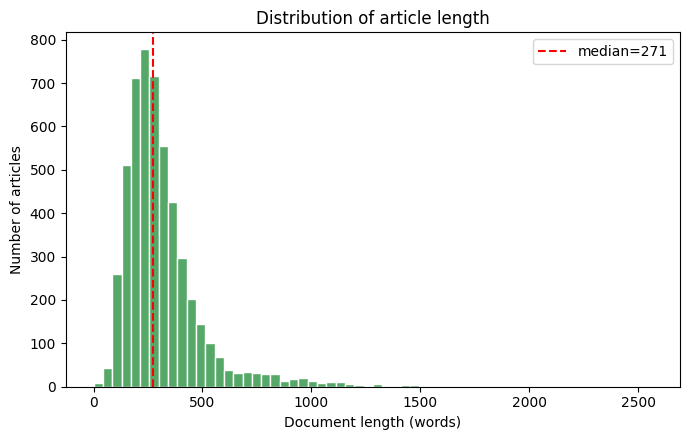

In [6]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(train['n_words'], bins=60, color='#55A868', edgecolor='white')
ax.axvline(train['n_words'].median(), color='red', linestyle='--', label=f"median={int(train['n_words'].median())}")
ax.set_xlabel("Document length (words)")
ax.set_ylabel("Number of articles")
ax.set_title("Distribution of article length")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig2_length_hist.png", dpi=150)
plt.show()

category
Kitaifa      322.0
michezo      254.0
Biashara     233.0
Kimataifa    132.0
Burudani      63.0
Name: n_words, dtype: float64


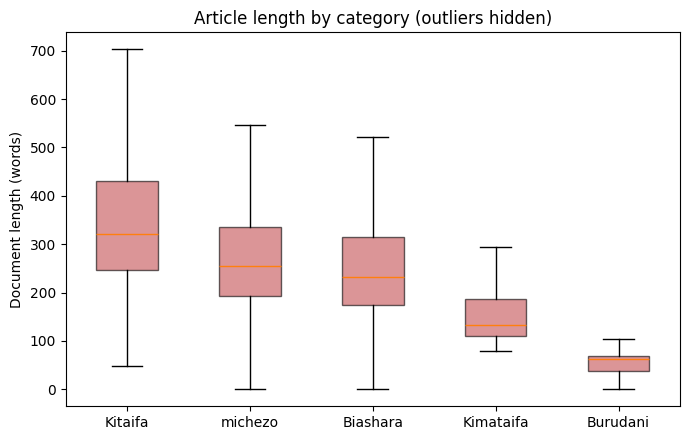

In [7]:
print(train.groupby('category')['n_words'].median().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7,4.5))
data_by_cat = [train[train.category==c]['n_words'].values for c in order]
bp = ax.boxplot(data_by_cat, tick_labels=order, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#C44E52'); patch.set_alpha(0.6)
ax.set_ylabel("Document length (words)")
ax.set_title("Article length by category (outliers hidden)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig3_length_by_category.png", dpi=150)
plt.show()

**Finding:** articles range from a handful of words to 2,564 words (median 271, 95th
percentile ≈ 680). Length also varies systematically by category — `Kitaifa` articles run
long (median ≈ 322 words) while `Burudani` articles are much shorter (median ≈ 63 words).
Since length correlates with the label, a model that only sees a truncated prefix of long
articles risks losing information disproportionately for some classes. A max sequence length
around 400–500 tokens covers roughly the 90th percentile while keeping training tractable;
this should be validated against whichever tokeniser (word-level vs. subword) is finally used.

## 4. Data quality: malformed records
A blind pass over the raw text surfaces a data-quality issue that isn't obvious from
summary statistics alone.

In [8]:
list_artifact = train['content'].str.contains(r"^\s*\[.*\]\s*$", regex=True)
print("Rows that are stringified Python list literals:", list_artifact.sum())
print(train[list_artifact]['category'].value_counts())
print()
print(repr(train.loc[list_artifact, 'content'].iloc[0][:300]))

Rows that are stringified Python list literals: 255
category
michezo    255
Name: count, dtype: int64

"['Mshambuliaji wa Real Madrid Gareth Bale anakaribia kuondoka katika klabu hiyo kulingana na mkufunzi wa klabu hiyo Zinedine Zidane. ', 'Mchezaji huyo wa taifa la Wales aliwachwa nje wakati Real Madrid ilipolazwa 3-1 na Bayern Munich nchini Marekani.', 'Akizungumza baada ya mechi hiyo, Zidane alisem"


**Finding:** 255 of the 1,720 `michezo` (sports) articles (about 14.8% of that class) are not plain text: they are Python list literals (`['para 1...', 'para 2...', ...]`), almost certainly an artefact of how multi-paragraph sports round-ups were scraped and stored. They still contain genuine Swahili, but mixed with literal `[`, `]`, `'` and escaped quotes, and they join several short bulletins (transfer-news digests) into one long "article". This (a) explains part of the heavy right skew in `michezo` length and (b) needs cleaning before tokenisation (`ast.literal_eval` and re-join, implemented in `src/data.py`); otherwise a word-level model wastes vocabulary slots on tokens such as `['mshambuliaji` and `psg',`.

Two further checks follow: near-empty documents and near-duplicate content.

In [9]:
print("Documents with 0 words:", (train['n_words']==0).sum())
print("Documents with <10 words:", (train['n_words']<10).sum())
print(train[train['n_words']<3][['id','category','content']])

Documents with 0 words: 1
Documents with <10 words: 3
          id  category content
2861  SW4225  Burudani       .
4906   SW724   michezo   ['.']
5006   SW832  Biashara        


Three records have fewer than 3 words (`.`, `['.']` and an empty string). They carry no information, so they are dropped in the shared cleaning step.

**Near-duplicates.** Exact duplicates were ruled out in Section 1, but the same story can be published twice with small edits. We compare every pair of articles by TF-IDF cosine similarity and flag pairs above 0.9.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(min_df=2, dtype=np.float32).fit_transform(train["content"].astype(str))
sim = cosine_similarity(tfidf)
np.fill_diagonal(sim, 0)
a, b = np.where(np.triu(sim, k=1) > 0.9)
pairs = pd.DataFrame({
    "id_a": train["id"].values[a], "id_b": train["id"].values[b],
    "similarity": sim[a, b].round(3),
    "category_a": train["category"].values[a], "category_b": train["category"].values[b],
})
del sim
print("Near-duplicate pairs (cosine > 0.9):", len(pairs))
print("Articles involved:", len(set(pairs["id_a"]) | set(pairs["id_b"])))
print("Pairs with different labels:", (pairs["category_a"] != pairs["category_b"]).sum())
pairs.sort_values("similarity", ascending=False).head(10)

Near-duplicate pairs (cosine > 0.9): 49
Articles involved: 95
Pairs with different labels: 8


,id_a,id_b,similarity,category_a,category_b
19,SW2289,SW4381,1.0,Kitaifa,Kitaifa
37,SW4050,SW5849,1.0,Kitaifa,Kitaifa
42,SW4682,SW5879,1.0,michezo,michezo
29,SW3449,SW3839,1.0,Kitaifa,Kitaifa
46,SW4970,SW795,1.0,Biashara,Kitaifa
27,SW3339,SW5111,1.0,Kitaifa,Kitaifa
44,SW4772,SW5412,1.0,Biashara,Kitaifa
1,SW11,SW688,1.0,michezo,michezo
22,SW2762,SW2788,1.0,Kitaifa,Kitaifa
43,SW4762,SW5380,1.0,Kitaifa,Kitaifa


In [11]:
split = pd.read_csv(DATA_DIR / "split_ids.csv").set_index("id")["split"]
pairs["split_a"] = split.reindex(pairs["id_a"]).to_numpy()
pairs["split_b"] = split.reindex(pairs["id_b"]).to_numpy()
crosses = pairs["split_a"].notna() & pairs["split_b"].notna() & (pairs["split_a"] != pairs["split_b"])
print("Pairs with similarity >= 0.99:", (pairs["similarity"] >= 0.99).sum())
print("Pairs split across train and validation:", crosses.sum())
print()
print("Label combinations of the conflicting pairs:")
print(pairs.loc[pairs["category_a"] != pairs["category_b"], ["category_a", "category_b"]].value_counts())

Pairs with similarity >= 0.99: 24
Pairs split across train and validation: 22

Label combinations of the conflicting pairs:
category_a  category_b
Biashara    Kitaifa       5
Kitaifa     Biashara      2
Kimataifa   Kitaifa       1
Name: count, dtype: int64


**Finding:** 49 pairs of articles (95 articles in total) are near-duplicates, and 24 pairs are practically identical (similarity ≥ 0.99): the same story published twice. This has two consequences:
- **Label noise.** 8 pairs carry *different* labels, and 7 of them are `Biashara` vs `Kitaifa`: the same text is labelled business news once and national news once. The boundary between these two classes is inconsistent in the annotations themselves, which limits the best achievable score on them.
- **Slight train/validation overlap.** 22 pairs are split across training and validation, so about 2% of validation articles have a near-copy in training. This inflates validation scores slightly and equally for all models. We keep the split fixed so every model is compared on exactly the same articles, and record this as a limitation.

## 5. Vocabulary and morphology
Swahili is a Bantu language with rich noun-class and verb morphology (agglutinative-like
prefixing/suffixing), which tends to inflate word-level vocabulary size relative to
English for a similarly sized corpus. This has a direct bearing on tokenisation choice.

In [12]:
def tokenize(text):
    return re.findall(r"[A-Za-zÀ-ÿ']+", str(text).lower())

all_tokens = []
for t in train['content']:
    all_tokens.extend(tokenize(t))

vocab = Counter(all_tokens)
hapax = sum(1 for w,c in vocab.items() if c == 1)

print("Total tokens:", len(all_tokens))
print("Vocabulary size (unique word-level tokens):", len(vocab))
print(f"Hapax legomena (appear once): {hapax} ({100*hapax/len(vocab):.1f}% of vocabulary)")
print()
print("Top 15 tokens overall (function words dominate, as expected):")
for w,c in vocab.most_common(15):
    print(f"  {w}: {c}")

Total tokens: 1628762
Vocabulary size (unique word-level tokens): 74006
Hapax legomena (appear once): 39604 (53.5% of vocabulary)

Top 15 tokens overall (function words dominate, as expected):
  ya: 87119
  na: 82488
  wa: 66559
  kwa: 39414
  katika: 21290
  za: 18678
  alisema: 18233
  ni: 15556
  la: 14776
  hiyo: 12514
  kuwa: 12366
  cha: 8792
  kwenye: 7699
  mwaka: 6745
  huo: 6464


**Finding:** the corpus has about 1.63 million word tokens but 74,006 distinct word forms, and 53.5% of those forms occur only once (hapax legomena). Much of this comes from Swahili morphology: one verb root appears with many subject, tense and object prefixes (*a-li-sema* "he/she said", *wa-na-sema* "they are saying", *a-li-mw-ambia* "he/she told him/her"), so a word-level vocabulary treats forms of the same word as unrelated symbols and sees most of them too rarely to learn from. Subword tokenisation (Sennrich et al., 2016; Kudo & Richardson, 2018) splits words into reusable pieces, so a rare form is still built from frequent parts. The neural models therefore use AfriBERTa's SentencePiece tokeniser, and the CNN is also trained on a word-level vocabulary as a controlled comparison (`03_neural_models.ipynb`).

### 5.1 Article length in subword tokens
The 400-500 word estimate in Section 3 counts words, but the neural models read **subword tokens**, and a Swahili word is often split into several pieces. AfriBERTa accepts at most 512 positions (510 tokens plus two special tokens), so we measure how many articles would actually be cut.

Subword tokens per word: 1.42
Articles longer than 510 subword tokens: 26.5%

           median_subwords  pct_over_510
category                                
Kitaifa              454.0          38.6
michezo              358.0          21.5
Biashara             320.5          16.2
Kimataifa            198.0           3.7
Burudani             100.0           0.0


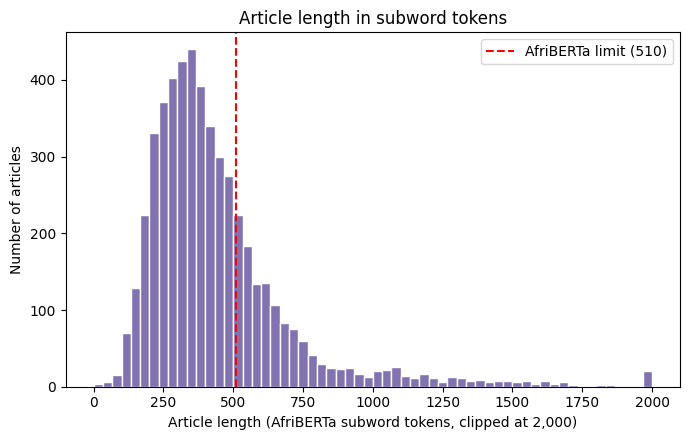

In [13]:
from src.text import load_subword_tokenizer, subword_lengths

tokenizer = load_subword_tokenizer()
cleaned = train["content"].apply(clean_content)
train["n_subwords"] = subword_lengths(cleaned, tokenizer)
words_clean = cleaned.str.split().apply(len)

print(f"Subword tokens per word: {train['n_subwords'].sum() / words_clean.sum():.2f}")
print(f"Articles longer than 510 subword tokens: {(train['n_subwords'] > 510).mean():.1%}")
print()
print(pd.DataFrame({
    "median_subwords": train.groupby("category")["n_subwords"].median(),
    "pct_over_510": train.groupby("category")["n_subwords"].apply(lambda s: 100 * (s > 510).mean()).round(1),
}).loc[order])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(train["n_subwords"].clip(upper=2000), bins=60, color="#8172B2", edgecolor="white")
ax.axvline(510, color="red", linestyle="--", label="AfriBERTa limit (510)")
ax.set_xlabel("Article length (AfriBERTa subword tokens, clipped at 2,000)")
ax.set_ylabel("Number of articles")
ax.set_title("Article length in subword tokens")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig4_subword_length_hist.png", dpi=150)
plt.show()

**Finding:** AfriBERTa's tokeniser produces 1.42 subword tokens per word, so articles are about 40% longer in tokens than in words. **26.5% of articles exceed the 510-token limit** and will be truncated by the neural models, far more than the roughly 10% suggested by the word counts in Section 3. Truncation also hits the classes unequally: 38.6% of `Kitaifa` articles are cut, but only 3.7% of `Kimataifa` and none of the `Burudani` articles.

This shapes three parts of the experimental design: head+tail truncation is tested for AfriBERTa, the BiLSTM is tested with 256 as well as 512 tokens, and the TF-IDF baseline is retrained on the first 510 tokens so that the comparison between bag-of-words and sequence models is not confounded by how much text each model sees.

## 6. Category separability (sanity check)
A quick lexical check — after removing very common function words, do the categories show
distinct, topically coherent vocabulary? This isn't a model, just evidence that the sequential
signal in the text is genuinely informative for classification.

In [14]:
sw_stop = set('''
ya na wa kwa katika za alisema ni la hiyo kuwa cha kwenye mwaka huo serikali
ili baada tanzania pia vya nchi nchini kutoka kama hilo hivyo wakati hayo
akisema aliongeza yake wake zake lake yao wao huyo hao hii huu hivi mmoja
watu mtu bwana bi wote wale kuhusu vile kutokana ambapo ambaye lakini au
kila si tu hata je bado kabla mno sana zaidi pale hapo huko
'''.split())

def clean_tokens(text):
    toks = re.findall(r"[A-Za-zÀ-ÿ']+", str(text).lower())
    return [t for t in toks if t not in sw_stop and len(t) > 2]

for cat in order:
    sub = train[train.category==cat]['content']
    toks = []
    for t in sub:
        toks.extend(clean_tokens(t))
    top = Counter(toks).most_common(10)
    print(f"--- {cat} (n={len(sub)}) ---")
    print(", ".join(f"{w}({c})" for w,c in top))
    print()

--- Kitaifa (n=2000) ---
mkuu(2267), rais(2237), kazi(2124), waziri(1990), wananchi(1929), fedha(1895), pamoja(1821), sasa(1715), mbalimbali(1665), hizo(1565)



--- michezo (n=1720) ---
timu(4298), mchezo(3490), simba(2374), ligi(2283), mechi(2042), yanga(1992), wachezaji(1974), klabu(1955), dhidi(1779), nafasi(1777)



--- Biashara (n=1360) ---
biashara(1434), huduma(1350), amesema(1263), kampuni(1158), viwanda(1101), sasa(1050), fedha(1035), benki(1014), mkuu(992), pamoja(972)

--- Kimataifa (n=54) ---
rais(57), amesema(34), marekani(34), kwamba(29), kenya(28), kampuni(28), china(27), siku(26), afrika(22), uingereza(21)

--- Burudani (n=17) ---
amesema(9), nafasi(7), brown(7), marekani(6), nigeria(6), taifa(6), kupitia(6), sasa(6), baadhi(5), duniani(4)



**Finding:** the top words per category are topically coherent and clearly separable even under a simple bag-of-words view: `michezo` surfaces *timu, mchezo, simba, ligi, mechi, yanga, wachezaji, klabu* (team, match, league, players, club, and the two dominant Tanzanian football clubs Simba SC and Yanga SC); `Biashara` surfaces *biashara, kampuni, viwanda, benki* (business, company, industry, bank). This means a keyword baseline such as TF-IDF should perform well, which is exactly why the study compares sequential neural models against non-sequential baselines: the comparison shows whether modelling word *order* and *context* adds value on top of this lexical signal.

The small classes are the exception. `Burudani`'s top words are dominated by names (*brown*, *nigeria*, *marekani*) rather than genre words, and `Kimataifa`'s by countries and leaders, so both depend on named entities that change over time.

**Code-switching check.** Sports articles mention foreign clubs and players (`Manchester`, `PSG`, `Barcelona`) inside Swahili sentences. To see whether English is used beyond proper nouns, we measure the share of tokens that are common English function words, which only appear when whole English phrases are used.

In [15]:
english = set('''the and of to in is that for on with was as by at from this are be it an or
have has not but they their which will were been would there'''.split())

def english_share(texts):
    toks = [t for text in texts for t in tokenize(text)]
    return 100 * sum(t in english for t in toks) / len(toks)

print(f"Common English function words, all articles: {english_share(train['content']):.2f}% of tokens")
print(pd.Series({c: round(english_share(train.loc[train.category == c, 'content']), 2) for c in order},
                name="% English function words"))

Common English function words, all articles: 0.05% of tokens


Kitaifa      0.02
michezo      0.12
Biashara     0.02
Kimataifa    0.09
Burudani     0.44
Name: % English function words, dtype: float64


**Finding:** common English function words make up only 0.05% of all tokens, so English appears almost only as proper nouns (clubs, companies, artists), not as code-switched phrases. `Burudani` has the highest share (0.44%), from English song titles and phrases in entertainment news, but it is still very small. Code-switching is therefore not a first-order concern for this dataset; foreign names are a minor source of rare tokens, which subword tokenisation handles by splitting them into known pieces.

## 7. Summary of findings and modelling implications

| Finding | Implication for sequential modelling |
|---|---|
| Severe class imbalance (2 classes below 2% of the data) | Macro-F1 as primary metric; stratified splitting; class-weighted loss (Section 8) |
| Long, right-skewed articles (median 271 words, up to 2,564); length varies by category | Truncation length matters; test whether reading more of the article helps (BiLSTM 256 vs 512 tokens, AfriBERTa head vs head+tail) |
| 26.5% of articles exceed AfriBERTa's 510-token limit (38.6% of `Kitaifa`, none of `Burudani`) | Truncation affects classes unequally; head+tail truncation for AfriBERTa; TF-IDF retrained on the first 510 tokens for a fair comparison |
| 255 `michezo` records are stringified Python lists; 3 near-empty records | Shared cleaning step in `src/data.py` before any tokenisation |
| 49 near-duplicate pairs; 8 with conflicting labels (7 `Biashara`/`Kitaifa`); 22 cross the train/validation split | Evidence of label noise between business and national news; small, equal inflation of validation scores (limitation) |
| Rich morphology (53.5% of word forms occur once) | Subword tokenisation for the neural models; word-level CNN as a controlled comparison |
| Categories are lexically well separated | TF-IDF baselines are a strong reference for judging whether word order adds value |
| Negligible code-switching (0.05% English function words); foreign proper nouns present | No special code-switching handling; subword tokens cover foreign names |

## 8. Evaluation metrics

The primary metric is **macro-averaged F1**: F1 is computed for each class separately and the five scores are averaged without weighting, so `Burudani` (17 articles) counts as much as `Kitaifa` (2,000). Accuracy and micro-F1 are dominated by the three large classes: a model that never predicts `Kimataifa` or `Burudani` loses at most 1.4 percentage points of accuracy. Sokolova and Lapalme (2009) show that accuracy-style measures hide poor performance on small classes and recommend macro averaging when every class matters equally. Opitz and Burst (2019) note that "macro-F1" is computed in two different ways in the literature; we use the arithmetic mean of per-class F1 scores (scikit-learn's `average="macro"`).

We also report:

| Metric | Why |
|---|---|
| Per-class F1 | Shows *where* a model fails; an average can hide a class with F1 = 0. |
| Macro-F1 over the 3 large classes | Separates "classifies news topics well" from "handles the two tiny classes". |
| Accuracy | Easy to interpret and comparable with earlier work on this data. |
| Log loss | Scores the predicted probabilities, not only the top label, so it rewards models that are confident when right and uncertain when wrong (Guo et al., 2017). It is also the challenge's leaderboard metric. |
| 95% bootstrap confidence interval of macro-F1 | The validation set has only 3 `Burudani` and 11 `Kimataifa` articles, so a single article moves macro-F1 by several points. Resampling the validation set 1,000 times (Efron & Tibshirani, 1993) shows how much of a gap between two models could be noise (Dror et al., 2018). |
| McNemar's test | Tests whether two models make significantly different errors on the same articles (Dietterich, 1998). |

**Limitations of this evaluation.** With 3 validation articles, `Burudani` F1 can only take a handful of values, and that one class can move macro-F1 by up to 0.2. We therefore compare models with confidence intervals and three-class macro-F1 as well, and treat differences inside overlapping intervals as inconclusive. Log loss is sensitive to a few confident mistakes, and class-weighted training deliberately shifts probabilities towards small classes, so a weighted model can have a worse log loss even when its macro-F1 improves.

## 9. Related work

### 9.1 The problem
The dataset contains Swahili articles from Tanzanian news websites, labelled with five categories (David, 2020). Swahili has over 100 million speakers but few labelled datasets. Classifying news automatically helps news sites sort and recommend articles, and is a building block for other Swahili language tools.

### 9.2 News classification in African languages
**MasakhaNEWS** (Adelani et al., 2023) compared simple models and pretrained transformers on news classification in 16 African languages, including Swahili. Two results matter for us:
- Transformers pretrained on African languages gave the best results.
- Simple keyword-based models were often close behind, because topic words are strong clues.

**AfriBERTa** (Ogueji et al., 2021) is one of these African-language transformers. It was pretrained on 11 African languages including Swahili, and matched much larger multilingual models. It is small enough to fine-tune on a free Colab GPU.

**SwahBERT** (Martin et al., 2022) was tested on a larger, six-category version of this news dataset (same source, same author). A model pretrained only on Swahili beat multilingual BERT, which confirms that a model that already knows Swahili has an advantage on this task.

### 9.3 Ways to model word order
| Model | Key paper | How it uses word order |
|---|---|---|
| TF-IDF + simple classifier | Wang & Manning (2012) | Ignores it: only counts words |
| CNN | Kim (2014) | Spots short phrases of a few words, anywhere in the text |
| (Bi)LSTM | Hochreiter & Schmidhuber (1997); Schuster & Paliwal (1997) | Reads word by word and keeps a memory of what came before |
| Transformer | Vaswani et al. (2017) | Every word looks at every other word at once |

### 9.4 Subword tokens
Swahili builds words by adding pieces to a root: *a-li-sema* ("he/she said"), *wa-na-sema* ("they are saying"). **Subword tokenisation** (Sennrich et al., 2016) splits words into these reusable pieces, so a rare word is still made of known parts. Because 53.5% of words appear only once, all three neural models use AfriBERTa's subword tokeniser.

### 9.5 Class imbalance and long documents
- **Class weighting.** Weighting the loss by inverse class frequency makes errors on small classes cost more. With our class sizes, full inverse-frequency weights would make one `Burudani` article count about 120 times as much as a `Kitaifa` article, which lets 13 training articles dominate the gradient. Cui et al. (2019) show that softened weights work better than raw inverse frequency when classes are very rare; we use the square root of the balanced weights for the neural models.
- **Naive Bayes and skewed classes.** Rennie et al. (2003) showed that multinomial Naive Bayes is biased towards large classes and proposed Complement Naive Bayes, which estimates each class from the documents of all *other* classes.
- **Long documents.** Transformers such as AfriBERTa read at most 512 tokens. Sun et al. (2019) found that keeping the first 128 and last 382 tokens ("head+tail") classified long documents better than keeping only the beginning.
- **Pooling in recurrent models.** A BiLSTM classifier that uses only its final hidden state must compress the whole article into one vector. Attention pooling (Yang et al., 2016) instead lets the model weight the most informative positions, which matters when key words can appear anywhere in a long article.

## 10. The five approaches

### Approach 1 (baseline): TF-IDF + Logistic Regression
- **What:** scores how important each word is in an article (TF-IDF), then learns which words point to which category.
- **Why:** each category has clear keywords, and MasakhaNEWS found this kind of model to be a strong baseline. It is fast, and its word weights show what it learned.
- **Limitation:** ignores word order and context. *Simba* the football club and *simba* the animal look the same.

### Approach 2 (baseline): TF-IDF + Naive Bayes
- **What:** learns how often each word appears in each category, then picks the most likely category for a new article.
- **Why:** the classic text classification baseline (Wang & Manning, 2012). It learns differently from logistic regression, so comparing the two shows how much the choice of simple model matters.
- **Variants tested:** standard multinomial NB, multinomial NB with a uniform class prior, and Complement NB (Rennie et al., 2003), which was designed for skewed class sizes.
- **Limitation:** assumes words are independent of each other, and tends to favour the large classes.

### Approach 3 (neural): 1D CNN
- **What:** slides a small window (e.g. 5 tokens) along the article to detect useful phrases, then keeps the strongest signal for each (Kim, 2014).
- **Variants tested:** with and without class weights, and subword vs word-level tokens.
- **Why:** topics are often signalled by short phrases such as *Ligi Kuu Tanzania* or *Benki Kuu*, which a CNN finds wherever they appear. It is also fast on long articles.
- **Limitation:** only sees a few tokens at a time, so it misses longer context.

### Approach 4 (neural): Bidirectional LSTM
- **What:** reads the article token by token, forwards and backwards, keeping a memory of what it has read (Hochreiter & Schmidhuber, 1997).
- **Variants tested:** final hidden state vs attention pooling (Yang et al., 2016), and 512 vs 256 input tokens.
- **Why:** articles are long (median 271 words), and the topic can depend on context spread across several sentences, which the CNN's short window cannot see. The LSTM carries a memory through the whole article, so comparing it with the CNN tests whether longer context helps more than short phrases.
- **Limitation:** its memory still fades over hundreds of tokens, so on long articles it may not beat the CNN. It is also slow, because it reads one token at a time, and learns only from our ~5k articles.

### Approach 5 (neural): Fine-tuned AfriBERTa
- **What:** a transformer already pretrained on African languages (Ogueji et al., 2021). We add a classification layer and train it further on our articles.
- **Variants tested:** with and without class weights, and first 510 tokens vs head+tail truncation (Sun et al., 2019).
- **Why:** research shows African-language pretrained models do best (MasakhaNEWS). Since it already knows Swahili, it should help most with the small classes (only 54 and 17 articles) and rare words.
- **Limitation:** reads only the first 512 tokens, so the end of long articles is lost, is the slowest to train, and is the hardest to explain.

### Summary

| | 1. TF-IDF + LR | 2. TF-IDF + NB | 3. CNN | 4. BiLSTM | 5. AfriBERTa |
|---|---|---|---|---|---|
| Type | Baseline | Baseline | Neural | Neural | Neural (pretrained) |
| Word order used | None | None | Short phrases | Whole sequence | Whole sequence |
| Input | TF-IDF word scores | TF-IDF word scores | Subword tokens | Subword tokens | Subword tokens |
| Text used | Whole article | Whole article | First 512 tokens | First 512 tokens | First 512 tokens |
| Speed | Very fast | Very fast | Fast | Slow | Slowest |

## 11. Experimental design

All five models use the same cleaned data and the same stratified 80/20 train/validation split (`data/split_ids.csv`: 4,118 training and 1,030 validation articles). The validation set is used only for reporting; every choice between settings is made on data the model was not trained on:
- **TF-IDF baselines:** 5-fold stratified cross-validation on the training part.
- **Neural models:** a stratified 10% development split of the training part, used for early stopping and for choosing between experiments.

| Model | Experiments | What changes | Question |
|---|---|---|---|
| TF-IDF + LR | `lr_unigram`, `lr_bigram`, `lr_unigram_unweighted` | n-gram range, class weights, `C` grid | Do word pairs add signal beyond keywords? Does class weighting help? |
| TF-IDF + NB | `nb_multinomial`, `nb_multinomial_uniform_prior`, `nb_complement` | NB variant and class prior | Does correcting for imbalance help a generative model? |
| CNN | `cnn_subword`, `cnn_subword_weighted`, `cnn_word_weighted` | class weights; subword vs word tokens | Do class weights rescue the small classes? Does subword tokenisation help with Swahili morphology? |
| BiLSTM | `bilstm_last`, `bilstm_attention`, `bilstm_best_256` | pooling; 512 vs 256 tokens | Does the LSTM memory fade over long articles? Does reading more text help? |
| AfriBERTa | `afriberta_head`, `afriberta_head_weighted`, `afriberta_head_tail` | class weights; truncation strategy | Does pretraining handle the small classes? Is the end of an article informative? |
| TF-IDF + LR | `lr_unigram_truncated510` | only the first 510 subword tokens | Is the comparison with 512-token neural models fair? |

Every experiment is recorded in `results/experiments.csv`.

## References

- Adelani, D. I., et al. (2023). MasakhaNEWS: News topic classification for African languages. *IJCNLP-AACL 2023*. https://aclanthology.org/2023.ijcnlp-main.10/
- Cui, Y., Jia, M., Lin, T.-Y., Song, Y., & Belongie, S. (2019). Class-balanced loss based on effective number of samples. *CVPR 2019*. https://arxiv.org/abs/1901.05555
- David, D. (2020). *Swahili: News Classification Dataset* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.4300294
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation, 10*(7), 1895–1923. https://doi.org/10.1162/089976698300017197
- Dror, R., Baumer, G., Shlomov, S., & Reichart, R. (2018). The hitchhiker's guide to testing statistical significance in natural language processing. *ACL 2018*. https://aclanthology.org/P18-1128/
- Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.
- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. *ICML 2017*. https://arxiv.org/abs/1706.04599
- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735
- Kim, Y. (2014). Convolutional neural networks for sentence classification. *EMNLP 2014*. https://aclanthology.org/D14-1181/
- Kudo, T., & Richardson, J. (2018). SentencePiece: A simple and language independent subword tokenizer and detokenizer for neural text processing. *EMNLP 2018 System Demonstrations*. https://aclanthology.org/D18-2012/
- Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization. *ICLR 2019*. https://arxiv.org/abs/1711.05101
- Martin, G. L., Mswahili, M. E., Jeong, Y.-S., & Woo, J. (2022). SwahBERT: Language model of Swahili. *NAACL 2022*. https://aclanthology.org/2022.naacl-main.23/
- Ogueji, K., Zhu, Y., & Lin, J. (2021). Small data? No problem! Exploring the viability of pretrained multilingual language models for low-resourced languages. *MRL Workshop, EMNLP 2021*. https://aclanthology.org/2021.mrl-1.11/
- Opitz, J., & Burst, S. (2019). Macro F1 and macro F1. *arXiv:1911.03347*. https://arxiv.org/abs/1911.03347
- Paszke, A., et al. (2019). PyTorch: An imperative style, high-performance deep learning library. *NeurIPS 2019*. https://arxiv.org/abs/1912.01703
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html
- Rennie, J. D. M., Shih, L., Teevan, J., & Karger, D. R. (2003). Tackling the poor assumptions of naive Bayes text classifiers. *ICML 2003*, 616–623.
- Schuster, M., & Paliwal, K. K. (1997). Bidirectional recurrent neural networks. *IEEE Transactions on Signal Processing, 45*(11), 2673–2681. https://doi.org/10.1109/78.650093
- Sennrich, R., Haddow, B., & Birch, A. (2016). Neural machine translation of rare words with subword units. *ACL 2016*. https://aclanthology.org/P16-1162/
- Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management, 45*(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002
- Sun, C., Qiu, X., Xu, Y., & Huang, X. (2019). How to fine-tune BERT for text classification? *CCL 2019*. https://arxiv.org/abs/1905.05583
- Vaswani, A., et al. (2017). Attention is all you need. *NeurIPS 2017*. https://arxiv.org/abs/1706.03762
- Wang, S., & Manning, C. D. (2012). Baselines and bigrams: Simple, good sentiment and topic classification. *ACL 2012*. https://aclanthology.org/P12-2018/
- Wolf, T., et al. (2020). Transformers: State-of-the-art natural language processing. *EMNLP 2020 System Demonstrations*. https://aclanthology.org/2020.emnlp-demos.6/
- Yang, Z., Yang, D., Dyer, C., He, X., Smola, A., & Hovy, E. (2016). Hierarchical attention networks for document classification. *NAACL 2016*. https://aclanthology.org/N16-1174/
- Zindi. (2020). *Swahili News Classification Challenge*. https://zindi.world/competitions/swahili-news-classification